In [3]:
! pip install -r requirements.txt

Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


In [9]:
! pip install pandas numpy matplotlib seaborn scikit-learn joblib

Defaulting to user installation because normal site-packages is not writeable


In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib
import os

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)
print('✅ Libraries imported successfully')

✅ Libraries imported successfully


In [11]:
df = pd.read_csv('youtube_ad_revenue_dataset.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (122400, 12)


,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008
3,vid_4078,2025-01-28 10:50:40.993199,10034,1191.0,242.0,31334.517771,11.770340,434482,Entertainment,Mobile,UK,224.638261
4,vid_3522,2025-04-28 10:50:40.993199,9889,1858.0,477.0,15665.666434,6.635854,42030,Education,Mobile,CA,165.514388


In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 122400 entries, 0 to 122399
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   video_id              122400 non-null  str    
 1   date                  122400 non-null  str    
 2   views                 122400 non-null  int64  
 3   likes                 116283 non-null  float64
 4   comments              116288 non-null  float64
 5   watch_time_minutes    116295 non-null  float64
 6   video_length_minutes  122400 non-null  float64
 7   subscribers           122400 non-null  int64  
 8   category              122400 non-null  str    
 9   device                122400 non-null  str    
 10  country               122400 non-null  str    
 11  ad_revenue_usd        122400 non-null  float64
dtypes: float64(5), int64(2), str(5)
memory usage: 16.9 MB


In [13]:
df.describe().round(2)

,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd
count,122400.00,116283.00,116288.00,116295.00,122400.00,122400.00,122400.00
mean,9999.86,1099.63,274.40,37543.83,16.01,502191.72,252.73
std,99.88,519.42,129.74,12987.72,8.08,288397.47,61.96
min,9521.00,195.00,48.00,14659.11,2.00,1005.00,126.59
25%,9933.00,650.00,162.00,26366.32,9.00,252507.50,199.90
50%,10000.00,1103.00,274.00,37531.99,16.01,503465.50,252.75
75%,10067.00,1547.00,387.00,48777.78,23.02,752192.00,305.60
max,10468.00,2061.00,515.00,61557.67,30.00,999997.00,382.77


In [14]:
#Handling the missing values and duplicates

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print('--- Missing Values ---')
print(missing_df)

dup_count = df.duplicated().sum()
print(f'\n--- Duplicate Rows: {dup_count} ({dup_count/len(df)*100:.2f}%) ---')

--- Missing Values ---
                    Missing Count  Missing %
likes                        6117       5.00
comments                     6112       4.99
watch_time_minutes           6105       4.99

--- Duplicate Rows: 2400 (1.96%) ---


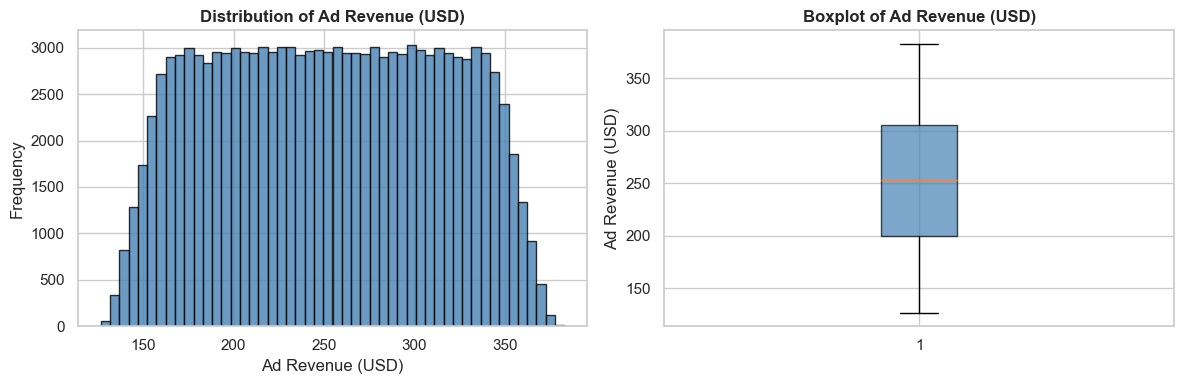

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['ad_revenue_usd'], bins=50, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Distribution of Ad Revenue (USD)', fontweight='bold')
axes[0].set_xlabel('Ad Revenue (USD)')
axes[0].set_ylabel('Frequency')

axes[1].boxplot(df['ad_revenue_usd'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[1].set_title('Boxplot of Ad Revenue (USD)', fontweight='bold')
axes[1].set_ylabel('Ad Revenue (USD)')

plt.tight_layout()
plt.show()

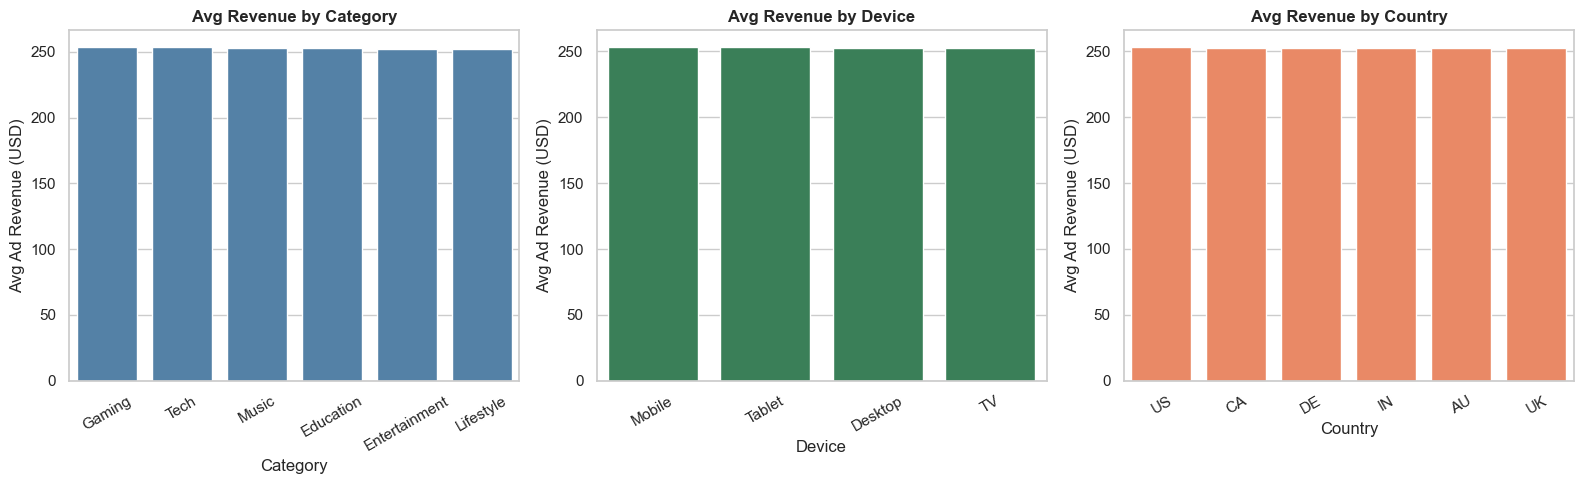

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, color in zip(axes, ['category', 'device', 'country'],
                           ['steelblue', 'seagreen', 'coral']):
    order = df.groupby(col)['ad_revenue_usd'].mean().sort_values(ascending=False).index
    sns.barplot(data=df, x=col, y='ad_revenue_usd', order=order,
                ax=ax, color=color, errorbar=None)
    ax.set_title(f'Avg Revenue by {col.capitalize()}', fontweight='bold')
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Avg Ad Revenue (USD)')
    ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

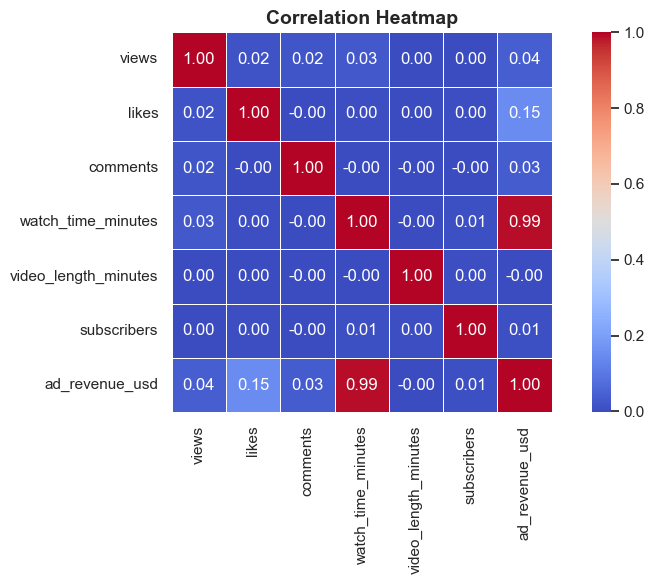


Correlations with ad_revenue_usd:
ad_revenue_usd          1.000000
watch_time_minutes      0.988874
likes                   0.146449
views                   0.038497
comments                0.034274
subscribers             0.005907
video_length_minutes   -0.000446
Name: ad_revenue_usd, dtype: float64


In [17]:
numeric_cols = ['views', 'likes', 'comments', 'watch_time_minutes',
                'video_length_minutes', 'subscribers', 'ad_revenue_usd']

corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nCorrelations with ad_revenue_usd:')
print(corr_matrix['ad_revenue_usd'].sort_values(ascending=False))

In [18]:
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
after = len(df)
print(f'Removed {before - after} duplicates. ({before:,} → {after:,} rows)')

Removed 2400 duplicates. (122,400 → 120,000 rows)


In [19]:
cols_with_missing = ['likes', 'comments', 'watch_time_minutes']
for col in cols_with_missing:
    median_val = df[col].median()
    missing_count = df[col].isnull().sum()
    df[col] = df[col].fillna(median_val)
    print(f'{col}: filled {missing_count} nulls with median ({median_val:.2f})')

print(f'\nRemaining nulls: {df.isnull().sum().sum()}')

likes: filled 6000 nulls with median (1102.00)
comments: filled 6000 nulls with median (274.00)
watch_time_minutes: filled 6000 nulls with median (37522.22)

Remaining nulls: 0


In [20]:
df['engagement_rate'] = (df['likes'] + df['comments']) / df['views']
df['avg_watch_time']  = df['watch_time_minutes'] / df['views']
df['like_ratio']      = df['likes'] / df['views']
df['date']            = pd.to_datetime(df['date'])
df['month']           = df['date'].dt.month

print('✅ New features: engagement_rate, avg_watch_time, like_ratio, month')
df.head(3)

✅ New features: engagement_rate, avg_watch_time, like_ratio, month


,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,category,device,country,ad_revenue_usd,engagement_rate,avg_watch_time,like_ratio,month
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,Entertainment,TV,IN,203.178237,0.155093,2.666789,0.122886,9
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,Gaming,Tablet,CA,140.880508,0.098632,1.518393,0.064091,9
2,vid_4784,2024-11-21 10:50:40.993199,10097,1979.0,187.0,57332.658498,26.200634,240534,Education,TV,CA,360.134008,0.214519,5.678187,0.195999,11


In [21]:
df_encoded = pd.get_dummies(df, columns=['category', 'device', 'country'], drop_first=True)
print(f'Shape after encoding: {df_encoded.shape}')
df_encoded.head(2)

Shape after encoding: (120000, 26)


,video_id,date,views,likes,comments,watch_time_minutes,video_length_minutes,subscribers,ad_revenue_usd,engagement_rate,...,category_Music,category_Tech,device_Mobile,device_TV,device_Tablet,country_CA,country_DE,country_IN,country_UK,country_US
0,vid_3092,2024-09-24 10:50:40.993199,9936,1221.0,320.0,26497.214184,2.862137,228086,203.178237,0.155093,...,False,False,False,True,False,False,False,True,False,False
1,vid_3459,2024-09-22 10:50:40.993199,10017,642.0,346.0,15209.747445,23.738069,736015,140.880508,0.098632,...,False,False,False,False,True,True,False,False,False,False


In [22]:
DROP_COLS = ['video_id', 'date']
TARGET    = 'ad_revenue_usd'

X = df_encoded.drop(columns=DROP_COLS + [TARGET])
y = df_encoded[TARGET]

print(f'Features: {X.shape}')
print(f'Target:   {y.shape}')
print(f'Columns: {X.columns.tolist()}')

Features: (120000, 23)
Target:   (120000,)
Columns: ['views', 'likes', 'comments', 'watch_time_minutes', 'video_length_minutes', 'subscribers', 'engagement_rate', 'avg_watch_time', 'like_ratio', 'month', 'category_Entertainment', 'category_Gaming', 'category_Lifestyle', 'category_Music', 'category_Tech', 'device_Mobile', 'device_TV', 'device_Tablet', 'country_CA', 'country_DE', 'country_IN', 'country_UK', 'country_US']


In [23]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}')
print('✅ Scaling done')

Train: 96,000 | Test: 24,000
✅ Scaling done


In [24]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    return {
        'Model': name,
        'R²':    round(r2_score(y_te, y_pred), 4),
        'RMSE':  round(np.sqrt(mean_squared_error(y_te, y_pred)), 4),
        'MAE':   round(mean_absolute_error(y_te, y_pred), 4),
        'model': model,
        'preds': y_pred
    }

models = [
    ('Linear Regression',  LinearRegression()),
    ('Ridge Regression',   Ridge(alpha=1.0)),
    ('Lasso Regression',   Lasso(alpha=0.01)),
    ('Random Forest',      RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)),
    ('Gradient Boosting',  GradientBoostingRegressor(n_estimators=100, random_state=42)),
]

results = []
trained_models = {}

for name, model in models:
    print(f'⏳ Training {name}...')
    res = evaluate_model(name, model, X_train_scaled, X_test_scaled, y_train, y_test)
    trained_models[name] = res.pop('model')
    preds = res.pop('preds')
    results.append(res)
    print(f'   R²={res["R²"]}  RMSE={res["RMSE"]}  MAE={res["MAE"]}')

print('\n✅ All models trained!')

⏳ Training Linear Regression...
   R²=0.9526  RMSE=13.4804  MAE=3.1131
⏳ Training Ridge Regression...
   R²=0.9526  RMSE=13.4805  MAE=3.1126
⏳ Training Lasso Regression...
   R²=0.9526  RMSE=13.4792  MAE=3.0941
⏳ Training Random Forest...
   R²=0.9499  RMSE=13.8595  MAE=3.5577
⏳ Training Gradient Boosting...
   R²=0.9522  RMSE=13.5294  MAE=3.6164

✅ All models trained!


In [26]:
results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
print('📊 Model Leaderboard:')
results_df

📊 Model Leaderboard:


,Model,R²,RMSE,MAE
0,Linear Regression,0.9526,13.4804,3.1131
1,Ridge Regression,0.9526,13.4805,3.1126
2,Lasso Regression,0.9526,13.4792,3.0941
3,Gradient Boosting,0.9522,13.5294,3.6164
4,Random Forest,0.9499,13.8595,3.5577


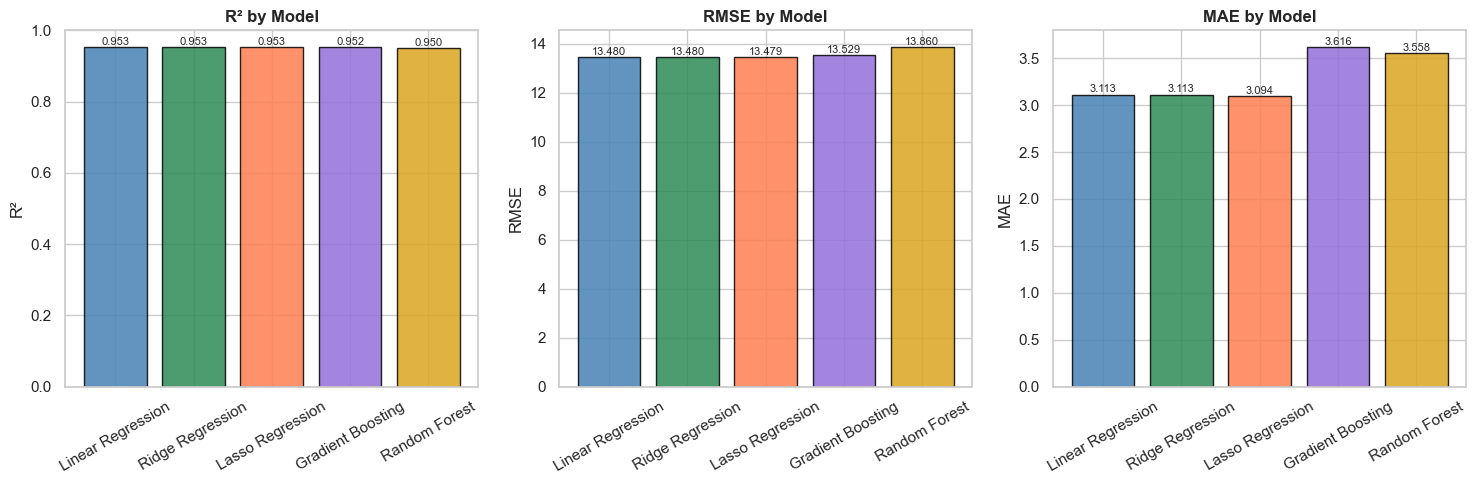

In [27]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['steelblue', 'seagreen', 'coral', 'mediumpurple', 'goldenrod']

for ax, metric in zip(axes, ['R²', 'RMSE', 'MAE']):
    bars = ax.bar(results_df['Model'], results_df[metric], color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(f'{metric} by Model', fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

🏆 Best Model: Linear Regression


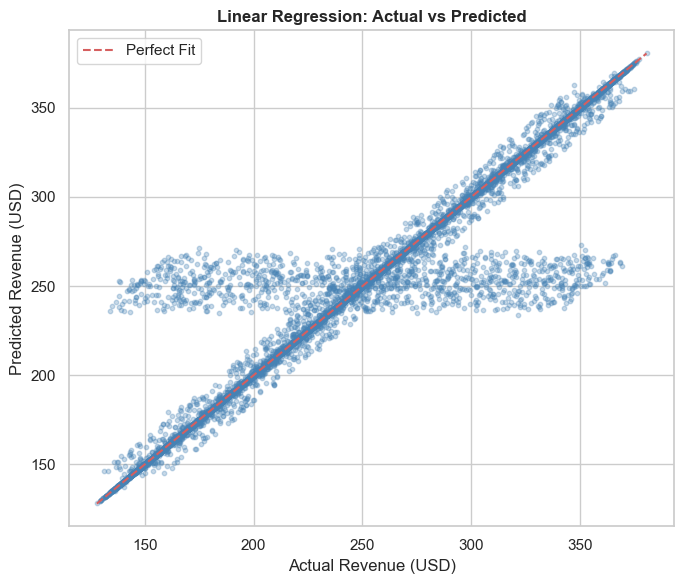

In [28]:
best_name  = results_df.iloc[0]['Model']
best_model = trained_models[best_name]
y_pred     = best_model.predict(X_test_scaled)

print(f'🏆 Best Model: {best_name}')

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred, alpha=0.3, s=10, color='steelblue')
min_val, max_val = y_test.min(), y_test.max()
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Fit')
plt.xlabel('Actual Revenue (USD)')
plt.ylabel('Predicted Revenue (USD)')
plt.title(f'{best_name}: Actual vs Predicted', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

In [29]:
if hasattr(best_model, 'feature_importances_'):
    importances = pd.Series(best_model.feature_importances_, index=X.columns)
    importances = importances.sort_values(ascending=False).head(15)

    plt.figure(figsize=(10, 5))
    importances.plot(kind='bar', color='steelblue', edgecolor='black')
    plt.title(f'Top 15 Feature Importances — {best_name}', fontweight='bold')
    plt.ylabel('Importance Score')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    print('\nTop 5 features:')
    print(importances.head())

In [ ]:
os.makedirs('model', exist_ok=True)
joblib.dump(best_model,          'model/best_model.pkl')
joblib.dump(scaler,              'model/scaler.pkl')
joblib.dump(list(X.columns),     'model/feature_columns.pkl')

print(f'✅ Saved best model: {best_name}')
print('✅ Saved scaler and feature columns')

✅ Saved best model: Linear Regression
✅ Saved scaler and feature columns


In [31]:
! pip install matplotlib seaborn scikit-learn joblib pandas

Defaulting to user installation because normal site-packages is not writeable
